# 09 — Comparison

Loads all `results_*.csv` files produced by notebooks 01-08 and produces comparison plots. **Does not re-run any experiments.** Run notebooks 01-08 first (in the same Colab runtime, or upload their CSVs here) so the `results_*.csv` files exist in the working directory.

## 1. Install + imports

In [1]:
!pip install -q pandas matplotlib
import glob
import pandas as pd
import matplotlib.pyplot as plt


## 2. Load all results CSVs

In [2]:
csv_paths = sorted(glob.glob("results_*.csv"))
print(f"Found {len(csv_paths)} results files:")
for p in csv_paths:
    print(" ", p)

if not csv_paths:
    raise FileNotFoundError(
        "No results_*.csv files found in the working directory. "
        "Run notebooks 01-08 first (same runtime) or upload their CSVs here."
    )

frames = []
for p in csv_paths:
    df = pd.read_csv(p)
    df["source_file"] = p
    frames.append(df)
all_results = pd.concat(frames, ignore_index=True, sort=False)
print(f"Combined {len(all_results)} rows across {len(csv_paths)} files")
all_results.head()


Found 8 results files:
  results_acorn.csv
  results_exact_filtered_search.csv
  results_hnsw_overfetch.csv
  results_hnsw_post_filter.csv
  results_ingraph_filtering.csv
  results_prefiltering.csv
  results_sieve.csv
  results_unify.csv
Combined 123 rows across 8 files


,method,filter,selectivity,recall_at_10,mean_latency_ms,p50_latency_ms,p95_latency_ms,qps,index_build_time_s,gamma,...,source_file,fetch_k,effective_ef,serving_choice,est_indexed_cost,est_bf_cost,strategy_chosen,cardinality,tau_A,tau_B
0,acorn_lite_hnswlib,sel100_unfiltered,100.000,1.0,1.151119,0.502202,2.626135,868.719621,2.209084,20.0,...,results_acorn.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,acorn_lite_hnswlib,sel75_label_ne_3,74.633,1.0,1.318111,0.620554,3.848715,758.661270,2.209084,20.0,...,results_acorn.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,acorn_lite_hnswlib,sel50_label_in_01,51.167,1.0,1.538322,1.082688,3.868895,650.058889,2.209084,20.0,...,results_acorn.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,acorn_lite_hnswlib,sel25_label_eq_0,25.600,1.0,1.946505,1.625024,5.096359,513.741327,2.209084,20.0,...,results_acorn.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,acorn_lite_hnswlib,sel25_label_eq_1,25.567,1.0,1.592635,1.604111,2.395041,627.890147,2.209084,20.0,...,results_acorn.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Recall@10 vs Selectivity

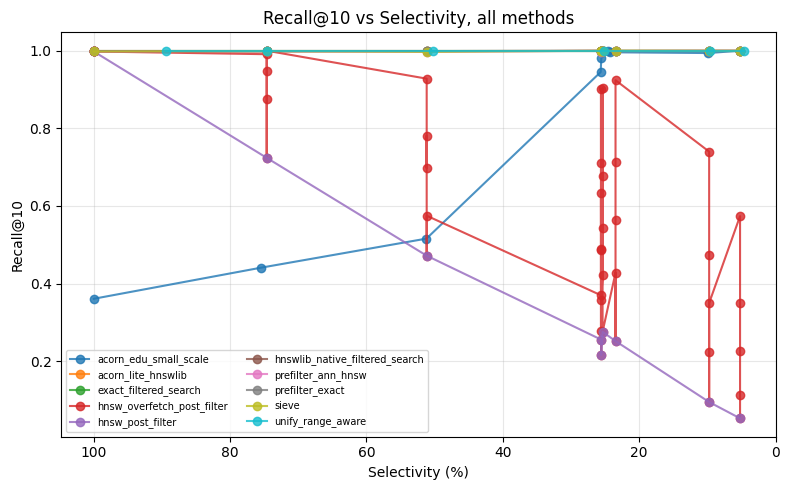

In [3]:
plt.figure(figsize=(8,5))
for method, sub in all_results.dropna(subset=["selectivity", "recall_at_10"]).groupby("method"):
    sub = sub.sort_values("selectivity")
    plt.plot(sub["selectivity"], sub["recall_at_10"], marker="o", label=method, alpha=0.8)
plt.xlabel("Selectivity (%)"); plt.ylabel("Recall@10")
plt.title("Recall@10 vs Selectivity, all methods")
plt.gca().invert_xaxis()
plt.legend(fontsize=7, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Mean Latency vs Selectivity

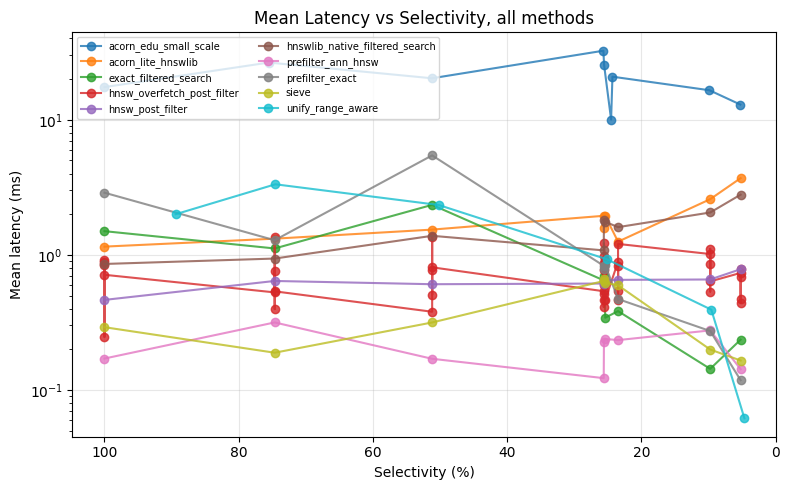

In [4]:
plt.figure(figsize=(8,5))
for method, sub in all_results.dropna(subset=["selectivity", "mean_latency_ms"]).groupby("method"):
    sub = sub.sort_values("selectivity")
    plt.plot(sub["selectivity"], sub["mean_latency_ms"], marker="o", label=method, alpha=0.8)
plt.xlabel("Selectivity (%)"); plt.ylabel("Mean latency (ms)")
plt.title("Mean Latency vs Selectivity, all methods")
plt.gca().invert_xaxis()
plt.yscale("log")
plt.legend(fontsize=7, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Recall vs Latency (the core trade-off curve)

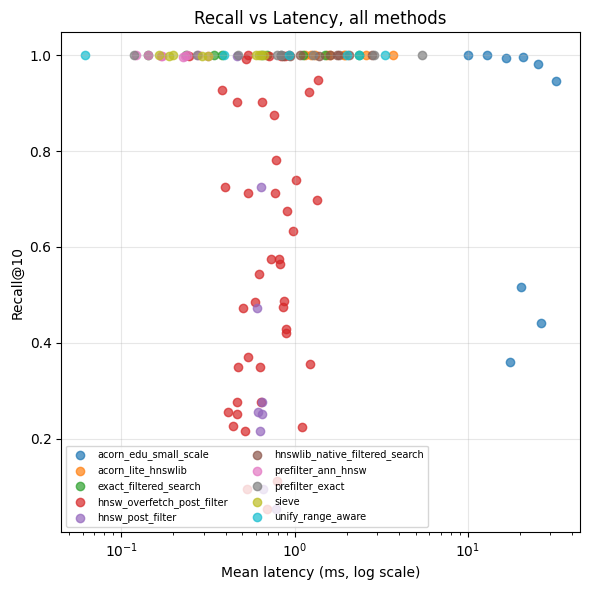

In [5]:
plt.figure(figsize=(6,6))
for method, sub in all_results.dropna(subset=["recall_at_10", "mean_latency_ms"]).groupby("method"):
    plt.scatter(sub["mean_latency_ms"], sub["recall_at_10"], label=method, alpha=0.7)
plt.xlabel("Mean latency (ms, log scale)"); plt.ylabel("Recall@10")
plt.xscale("log")
plt.title("Recall vs Latency, all methods")
plt.legend(fontsize=7, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Overfetch vs Recall (Notebook 03 data)

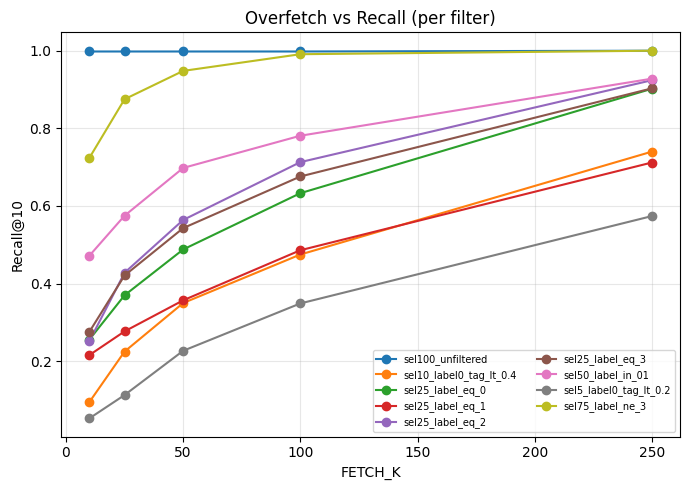

In [6]:
of_df = all_results[all_results["method"] == "hnsw_overfetch_post_filter"]
if len(of_df):
    plt.figure(figsize=(7,5))
    for filt, sub in of_df.groupby("filter"):
        sub = sub.sort_values("fetch_k")
        plt.plot(sub["fetch_k"], sub["recall_at_10"], marker="o", label=filt)
    plt.xlabel("FETCH_K"); plt.ylabel("Recall@10")
    plt.title("Overfetch vs Recall (per filter)")
    plt.legend(fontsize=7, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No hnsw_overfetch_post_filter rows found — run Notebook 03 first.")


## 7. Overfetch vs Latency (Notebook 03 data)

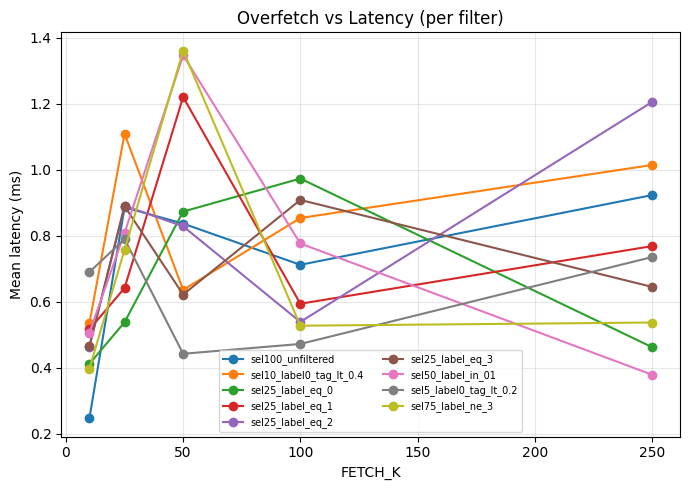

In [7]:
if len(of_df):
    plt.figure(figsize=(7,5))
    for filt, sub in of_df.groupby("filter"):
        sub = sub.sort_values("fetch_k")
        plt.plot(sub["fetch_k"], sub["mean_latency_ms"], marker="o", label=filt)
    plt.xlabel("FETCH_K"); plt.ylabel("Mean latency (ms)")
    plt.title("Overfetch vs Latency (per filter)")
    plt.legend(fontsize=7, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No hnsw_overfetch_post_filter rows found — run Notebook 03 first.")


## 8. Strategy choice (pre/post/hybrid) vs Range Selectivity — Notebook 08 only

New plot vs. the original list, since Notebook 08 (UNIFY) now has a genuine range-aware strategy switch worth visualizing.

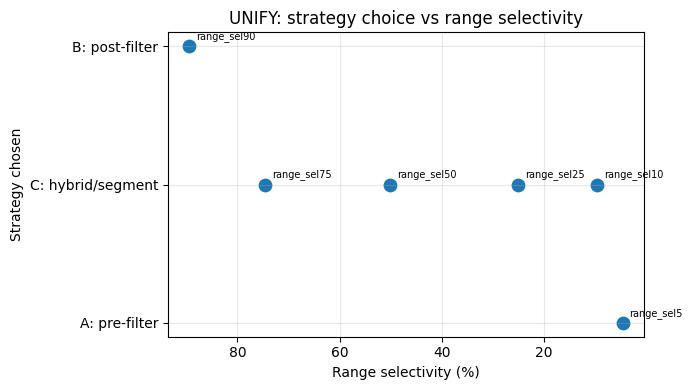

In [8]:
unify_df = all_results[all_results["method"] == "unify_range_aware"]
if len(unify_df):
    strategy_map = {"A": 0, "C": 1, "B": 2}  # pre -> hybrid -> post, for plotting order
    plot_df = unify_df.sort_values("selectivity").copy()
    plot_df["strategy_y"] = plot_df["strategy_chosen"].map(strategy_map)
    plt.figure(figsize=(7,4))
    plt.scatter(plot_df["selectivity"], plot_df["strategy_y"], s=80)
    for _, row in plot_df.iterrows():
        plt.annotate(row["filter"], (row["selectivity"], row["strategy_y"]),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)
    plt.yticks([0, 1, 2], ["A: pre-filter", "C: hybrid/segment", "B: post-filter"])
    plt.xlabel("Range selectivity (%)"); plt.ylabel("Strategy chosen")
    plt.title("UNIFY: strategy choice vs range selectivity")
    plt.gca().invert_xaxis()
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No unify_range_aware rows found — run Notebook 08 first.")


## 9. Summary table

In [9]:
summary = (all_results.groupby("method")
           .agg(n_rows=("method", "count"),
                mean_recall=("recall_at_10", "mean"),
                mean_latency_ms=("mean_latency_ms", "mean"),
                mean_qps=("qps", "mean"))
           .sort_values("mean_recall", ascending=False))
summary


,n_rows,mean_recall,mean_latency_ms,mean_qps
method,,,,
acorn_lite_hnswlib,9,1.000000,1.890804,599.030106
exact_filtered_search,9,1.000000,0.823013,2413.527427
unify_range_aware,6,1.000000,1.509009,3512.814886
prefilter_exact,9,1.000000,1.438306,2135.835216
hnswlib_native_filtered_search,9,0.999444,1.585462,719.290877
sieve,9,0.999333,0.409030,3259.006941
prefilter_ann_hnsw,9,0.998778,0.210859,5175.430932
acorn_edu_small_scale,9,0.803778,20.306705,55.464609
hnsw_overfetch_post_filter,45,0.590711,0.727557,1569.870434
